In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Part 0: Conceptual Warm Up

If a strategy is making money 70% of the time, it may seem automatically safe, but this is not necessarily true. A 70% win rate suggests that there is a 30% probability that it is not making money. It may seem logical to choose the strategy because 70% represents a clear majority. However, in a hypothetical example, 70% of the time the strategy may work on a very low-risk basis consistently, where it returns 5% frequently, but when it does not work it may cause a drastic loss, of say -20%. This way of evaluating strategy success is not viable as it does not tell the whole story of risk and analysing the potential upsides and downsides depending on if you are successful or not. Determining whether a strategy is safe depends not only on the frequency of wins, but also on the magnitude of losses, the overall distribution of returns, and the ability to recover from significant losses.


# Part 1: Create Your Own Little Market

Below is the hypothetical code I would have run if I had not had an issue with the seed value...

In [2]:
# PERSONAL_SEED = 23 # Personal Seed Reflects My Age
# np.random.seed(PERSONAL_SEED)

In [3]:
# 60-day price series starting at 50
# start_price = 50
# days = 60
# noise_volatility = 0.5
# daily_noise = np.random.normal(0, noise_volatility, days)

In [4]:
# daily_noise[0] = 0
# prices = start_price + np.cumsum(daily_noise)

Reminder about my email - I had an issue with the seed value so am loading in the data here to make it reproducable for the sake off my write-ups that were completed prior to realizing... Thank you for being understanding!

Here is where I loaded in my data that I had written about prior to realising my mistake with the seed values...

In [5]:
import io

data = """Day      Price
		0     1  50.000000
		1     2  49.593192
		2     3  49.945004
		3     4  49.810933
		4     5  49.569653
		5     6  50.191958
		6     7  50.530388
		7     8  52.124140
		8     9  51.583857
		9    10  51.588972
		10   11  51.807887
		11   12  52.471780
		12   13  52.346208
		13   14  53.142763
		14   15  53.228172
		15   16  52.873545
		16   17  52.807033
		17   18  52.798354
		18   19  52.747808
		19   20  52.465788
		20   21  52.376270
		21   22  52.881800
		22   23  53.342298
		23   24  54.308843
		24   25  53.911161
		25   26  53.405393
		26   27  54.480783
		27   28  54.693353
		28   29  54.913929
		29   30  54.505209
		30   31  54.724156
		31   32  54.774017
		32   33  54.806720
		33   34  55.418936
		34   35  55.034136
		35   36  55.130196
		36   37  54.268569
		37   38  54.499199
		38   39  53.956516
		39   40  54.868205
		40   41  54.201773
		41   42  55.020469
		42   43  54.608999
		43   44  53.809945
		44   45  53.923201
		45   46  54.040150
		46   47  53.566538
		47   48  52.935750
		48   49  51.740817
		49   50  51.574180
		50   51  51.745939
		51   52  50.732008
		52   53  50.797717
		53   54  51.599334
		54   55  50.717177
		55   56  51.000429
		56   57  51.274823
		57   58  50.967255
		58   59  51.129028
		59   60  50.577431"""
df = pd.read_csv(io.StringIO(data), sep=r'\s\s+', engine='python')

In [6]:
# Display first 10 rows
df.head(10)

,Day,Price
0,1,50.000000
1,2,49.593192
2,3,49.945004
3,4,49.810933
4,5,49.569653
5,6,50.191958
6,7,50.530388
7,8,52.124140
8,9,51.583857
9,10,51.588972


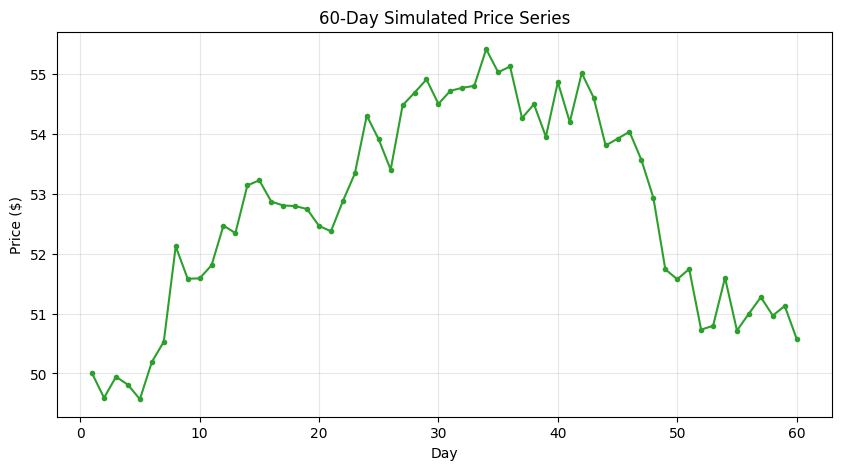

In [7]:
# Plot series price
plt.figure(figsize=(10, 5))
plt.plot(df['Day'], df['Price'], marker='.', linestyle='-', color='#2ca02c')
plt.title('60-Day Simulated Price Series')
plt.xlabel('Day')
plt.ylabel('Price ($)')
plt.grid(True, alpha=0.3)
plt.show()

I chose the seed value because it is my age, 23 years old (or would have, if things had gone to plan...)


The price on day 20 of my series is roughly \$52.46.

My series trends both up and down throughout the 60 day period. As set, the price begins at \$50, and begins to trend upwards for the first 35 days, peaking at a price of roughly \$55.50. From this point onwards, we then see the price begin to decrease over the remaining 25 days, where the price eventually ends the 60 day period at \$50.60. These descriptions of the price change over the 60 day period demonstrates the general trends, however, it is important to know that on a day-to-day basis, there are fluctuations of small increases and decreases that occur. This tells us that although there are general trends occuring over this specific time window, there are still differences on a micro level that are important to consider when analyzing price changes.


If I had to guess tomorrow's price, I would guess that it is going to be \$51. This is because the price over the days prior have fluctuated around that price, and I am expecting that the overall price is going to head on a general trend of increasing as it did that last time it was in the \$50-51 price range. However, it is important to understand that this is purely a guess, and to make any further estimations of tomorrow's price there are better ways of forecasting this.


My chart feels generally pretty calm. This is because over the range of a 60 day period, we see the price fluctuate within a \$5.50 range. While we are missing a large amount of context about this price series, I believe that it has remained within a reasonable range despite the general trends discussed prior, as well as the daily price changes. If I were to see the price changing within this range daily and with less consistent upwards or downard trends, we may say that it is volatile, but the small daily changes that create these trends lead me to believe that on the whole it is pretty calm.

# Part 2: Invent a Simple Trading Rule

In [8]:
positions = []
actions = []
current_position = 0

In [9]:
current_pos = 0  # start with no position
positions = []
actions = []

for price in df["Price"]:

    # Apply rule
    if price > 52:
        desired_pos = -1   # short
    elif price < 48:
        desired_pos = 1    # long
    else:
        desired_pos = 0    # hold / flat

    # Execute trade only if position changes
    if desired_pos == 1 and current_pos != 1:
        action = "GO LONG"
        current_pos = 1
    elif desired_pos == -1 and current_pos != -1:
        action = "GO SHORT"
        current_pos = -1
    else:
        action = "HOLD"

    positions.append(current_pos)
    actions.append(action)

In [10]:
df['Position'] = positions
df['Action'] = actions

In [11]:
print("\n--- Part 2: Full Trading Table ---")
print(df.to_string())


--- Part 2: Full Trading Table ---
    Day      Price  Position    Action
0     1  50.000000         0      HOLD
1     2  49.593192         0      HOLD
2     3  49.945004         0      HOLD
3     4  49.810933         0      HOLD
4     5  49.569653         0      HOLD
5     6  50.191958         0      HOLD
6     7  50.530388         0      HOLD
7     8  52.124140        -1  GO SHORT
8     9  51.583857        -1      HOLD
9    10  51.588972        -1      HOLD
10   11  51.807887        -1      HOLD
11   12  52.471780        -1      HOLD
12   13  52.346208        -1      HOLD
13   14  53.142763        -1      HOLD
14   15  53.228172        -1      HOLD
15   16  52.873545        -1      HOLD
16   17  52.807033        -1      HOLD
17   18  52.798354        -1      HOLD
18   19  52.747808        -1      HOLD
19   20  52.465788        -1      HOLD
20   21  52.376270        -1      HOLD
21   22  52.881800        -1      HOLD
22   23  53.342298        -1      HOLD
23   24  54.308843        -1

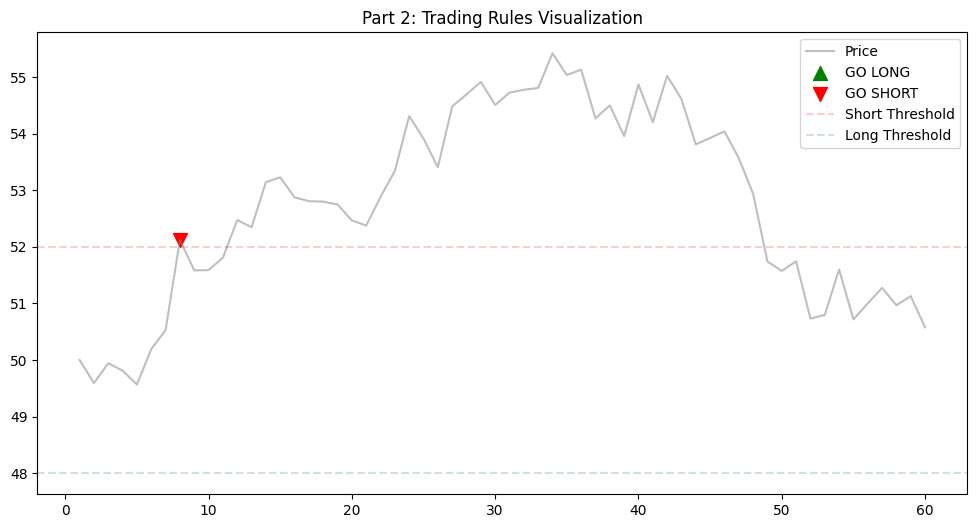

In [12]:
# Plot with Buy/Sell Markers
plt.figure(figsize=(12, 6))
plt.plot(df['Day'], df['Price'], color='gray', alpha=0.5, label='Price')

# Identify markers for the plot
buys = df[df['Action'] == "GO LONG"]
sells = df[df['Action'] == "GO SHORT"]

plt.scatter(buys['Day'], buys['Price'], color='green', marker='^', label='GO LONG', s=100)
plt.scatter(sells['Day'], sells['Price'], color='red', marker='v', label='GO SHORT', s=100)

plt.axhline(52, color='red', linestyle='--', alpha=0.2, label='Short Threshold')
plt.axhline(48, color='green', linestyle='--', alpha=0.2, label='Long Threshold')

plt.title('Part 2: Trading Rules Visualization')
plt.legend()
plt.show()

In [13]:
num_trades = df[df['Action'] != 'HOLD'].shape[0]
num_longs = df[df['Action'] == 'GO LONG'].shape[0]
num_shorts = df[df['Action'] == 'GO SHORT'].shape[0]

print(f"You made a total of {num_trades} trades (excluding 'HOLD' actions).")
print(f"  - {num_longs} 'GO LONG' trades")
print(f"  - {num_shorts} 'GO SHORT' trades")

You made a total of 1 trades (excluding 'HOLD' actions).
  - 0 'GO LONG' trades
  - 1 'GO SHORT' trades


I made my first trade on day 8, where I shorted at the price of \$52.12.

I made 1  'GO SHORT' trade, which accounted for all of the total trades that I made. There were no 'GO LONG' trades made.

Honestly, no. This rule did not feel reasonable for this series as there was only one short position and no long positions taken at all. There were no points where the price dropped below \$48, so the long position was never triggered. Additonally, there was a prolonged period of time after the short where the position occured losses, without a clear exit stretegy. The strategy was stuck in lopsided exposure to the short. The overall performance was due to a significant recovery, but this is not a reproducable account of what may happen if this rule was to be repeated. This strategy succeeded only due to the trend reversal before the loses became too big.

Since that there were only short values taken above the \$52 dollar price range, the short position looked poorly timed as it occured at a period of time where there was a sustained upwards trend. As the price continued to rise, the position experienced a significant losses (entered at \$52.12m peaked at \$55.42, representing a \$3.30 adverse move) before eventually reversing. While there was only one short trade, it was exposed to long-term trend risk as the price continued to rise for several weeks after the short was made, meaning there was unrealized loss before eventuall reversing.

# Part 3: Turn Actions Into Money

In [25]:
# Calculate Daily P&L
# Exposure is $1,000 per unit (Position 1 = $1000, Position -1 = -$1000)
exposure = 1000

# Daily Price Change: Price(today) - Price(yesterday)
df['Price_Change'] = df['Price'].diff()

# Daily P&L = Position(yesterday) * Price_Change(today) * (Exposure / StartPrice)
df['Daily_PnL'] = df['Position'].shift(1) * df['Price_Change'] * (exposure / 50)
df['Daily_PnL'] = df['Daily_PnL'].fillna(0) # First day has no P&L

# Calculate Cumulative P&L
df['Cumulative_PnL'] = df['Daily_PnL'].cumsum()

# Table displaying results for all 60 days
print("\n--- PART 3: Full Financial Results ---")
pd.set_option('display.max_rows', None) # Ensure all 60 days print
print(df[['Day', 'Price', 'Position', 'Action', 'Daily_PnL', 'Cumulative_PnL']].to_string(index=False))


--- PART 3: Full Financial Results ---
 Day     Price  Position   Action  Daily_PnL  Cumulative_PnL
   1 50.000000         0     HOLD    0.00000         0.00000
   2 49.593192         0     HOLD   -0.00000         0.00000
   3 49.945004         0     HOLD    0.00000         0.00000
   4 49.810933         0     HOLD   -0.00000         0.00000
   5 49.569653         0     HOLD   -0.00000         0.00000
   6 50.191958         0     HOLD    0.00000         0.00000
   7 50.530388         0     HOLD    0.00000         0.00000
   8 52.124140        -1 GO SHORT    0.00000         0.00000
   9 51.583857        -1     HOLD   10.80566        10.80566
  10 51.588972        -1     HOLD   -0.10230        10.70336
  11 51.807887        -1     HOLD   -4.37830         6.32506
  12 52.471780        -1     HOLD  -13.27786        -6.95280
  13 52.346208        -1     HOLD    2.51144        -4.44136
  14 53.142763        -1     HOLD  -15.93110       -20.37246
  15 53.228172        -1     HOLD   -1.70818 

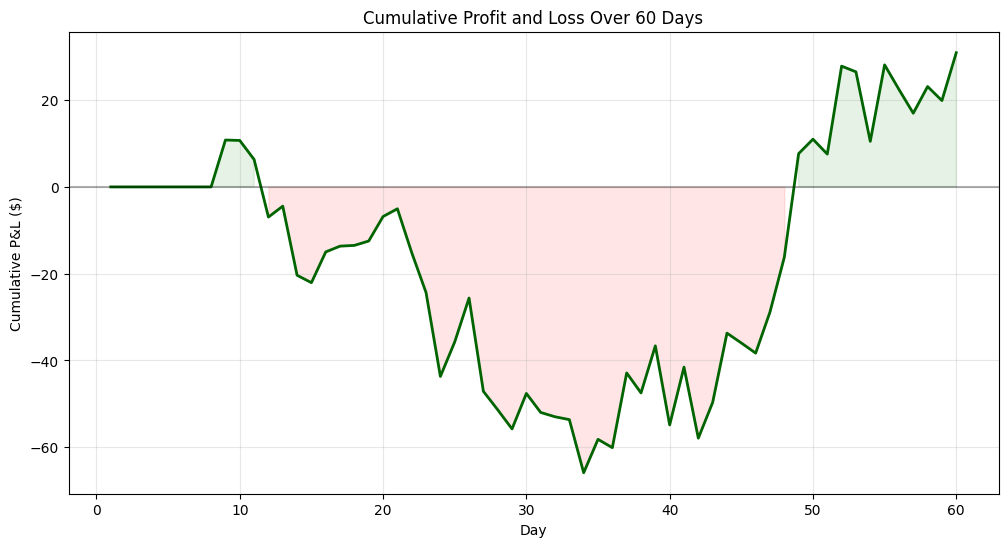

In [26]:
# Plot of Cumulative P&L
plt.figure(figsize=(12, 6))
plt.plot(df['Day'], df['Cumulative_PnL'], color='darkgreen', linewidth=2)
plt.axhline(0, color='black', linestyle='-', alpha=0.3)
plt.title('Cumulative Profit and Loss Over 60 Days')
plt.xlabel('Day')
plt.ylabel('Cumulative P&L ($)')
plt.grid(True, alpha=0.3)
plt.fill_between(df['Day'], df['Cumulative_PnL'], 0, where=(df['Cumulative_PnL'] >= 0), color='green', alpha=0.1)
plt.fill_between(df['Day'], df['Cumulative_PnL'], 0, where=(df['Cumulative_PnL'] < 0), color='red', alpha=0.1)
plt.show()

By day 30, I was down \$-47.62 dollars.

My final cummulative profit was \$30.93, which shows that I made a substantial recovery of close to \$80 dollars by the time I reached day 60. This recovery is important because it shows that I was able to recovery to from a deficit 2x as larged as the final profits, suggesting that the final outcome for this time window is purely down to timing of when the window ends. If the window had ended on day 34, there would be a very different outcome. This shows that this trading is highly path dependent and depends when the sample ends

Yes, I experienced a very significant losing streak for 36 days straight. It started at day 12, where my cummulative profits went below \$0 for the first time at a value of \$-6.95, reaching its biggest cummualtive loss in day 34, where the price was \$-65.89. The last day in a loss was day 48, where the price was at a loss of \$-16.23. On day 49, the price then became positive again and remained so for the rest of this price window.

Overall, the strategy saw a maximum drawdown of \$-65.89, and ended up ultimately earning \$30.93, meaning the maximum loss was more than twice the final profits.  While the overall startegy worked, the combination of time in loss and signficant bounceback to be profitable by the end of the window shows their is limited risk control and future outcomes are fragile.

# Part 4: Add Leverage

In [27]:
# Calculate 10x Exposure
leverage_factor = 10
exposure_1x = 1000
exposure_10x = exposure_1x * leverage_factor

# Calculate Daily and Cumulative P&L for both versions
# Using (exposure / 50) as the multiplier for price movement points
multiplier_1x = exposure_1x / 50
multiplier_10x = exposure_10x / 50

# P&L 1x
df['Daily_PnL_1x'] = df['Position'].shift(1) * df['Price_Change'] * multiplier_1x
df['Daily_PnL_1x'] = df['Daily_PnL_1x'].fillna(0)
df['Cumulative_PnL_1x'] = df['Daily_PnL_1x'].cumsum()

# P&L 10x
df['Daily_PnL_10x'] = df['Position'].shift(1) * df['Price_Change'] * multiplier_10x
df['Daily_PnL_10x'] = df['Daily_PnL_10x'].fillna(0)
df['Cumulative_PnL_10x'] = df['Daily_PnL_10x'].cumsum()


In [17]:
# Table displaying results for all 60 days including both 1x and 10x
print("\n--- PART 4: Full Leveraged Results (1x vs 10x) ---")
cols_to_show = ['Day', 'Price', 'Position', 'Daily_PnL_1x', 'Cumulative_PnL_1x', 'Daily_PnL_10x', 'Cumulative_PnL_10x']
print(df[cols_to_show].to_string(index=False))


--- PART 4: Full Leveraged Results (1x vs 10x) ---
 Day     Price  Position  Daily_PnL_1x  Cumulative_PnL_1x  Daily_PnL_10x  Cumulative_PnL_10x
   1 50.000000         0       0.00000            0.00000         0.0000              0.0000
   2 49.593192         0      -0.00000            0.00000        -0.0000              0.0000
   3 49.945004         0       0.00000            0.00000         0.0000              0.0000
   4 49.810933         0      -0.00000            0.00000        -0.0000              0.0000
   5 49.569653         0      -0.00000            0.00000        -0.0000              0.0000
   6 50.191958         0       0.00000            0.00000         0.0000              0.0000
   7 50.530388         0       0.00000            0.00000         0.0000              0.0000
   8 52.124140        -1       0.00000            0.00000         0.0000              0.0000
   9 51.583857        -1      10.80566           10.80566       108.0566            108.0566
  10 51.588972    

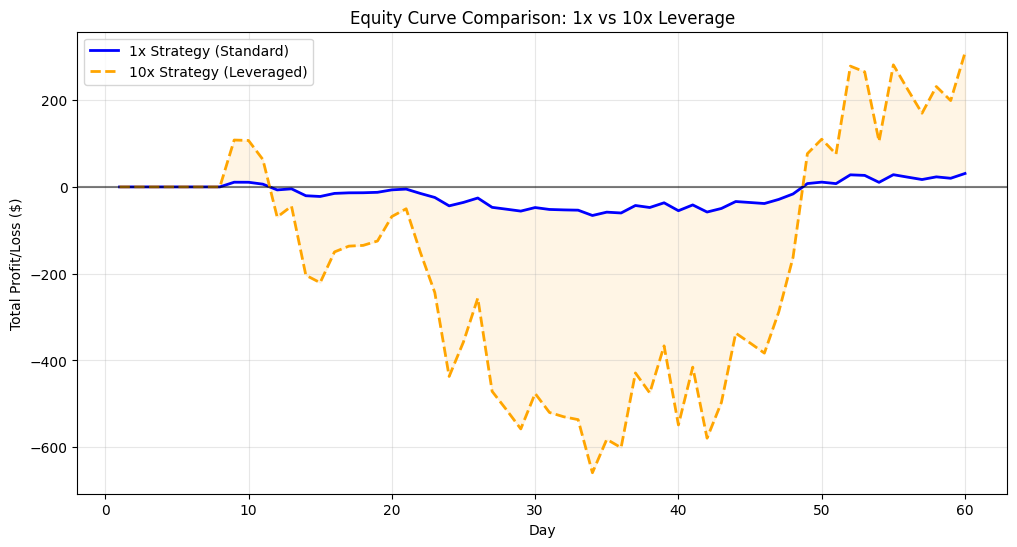

In [28]:
# Plot Equity Curves together
plt.figure(figsize=(12, 6))

# Plotting both curves
plt.plot(df['Day'], df['Cumulative_PnL_1x'], label='1x Strategy (Standard)', color='blue', linewidth=2)
plt.plot(df['Day'], df['Cumulative_PnL_10x'], label='10x Strategy (Leveraged)', color='orange', linewidth=2, linestyle='--')

# Formatting the chart
plt.axhline(0, color='black', alpha=0.5)
plt.title('Equity Curve Comparison: 1x vs 10x Leverage')
plt.xlabel('Day')
plt.ylabel('Total Profit/Loss ($)')
plt.legend()
plt.grid(True, alpha=0.3)

# Adding shading to highlight the magnitude difference
plt.fill_between(df['Day'], df['Cumulative_PnL_10x'], df['Cumulative_PnL_1x'], color='orange', alpha=0.1)

plt.show()

Yes, the leverage did change my final profits. At 10x leverage, my final cummulative profit is \$309.34, which is substaintially bigger than the cummulative profit when I was unleveraged. This is inly a mechanical difference, as the leverage magnified my volatility, but does not fundamentally change the strategy of the trades made.

Yes, for sure. As we became more leveraged (10x), the changes in the price meant that the size of profit and losses were larger. At the points in which the losses were at their largest, we had a cummulative loss of greater than \$-658.959237 dollars. However, it is important to note that while the 'scariness' of the potential increased losses is matched in the opposite effect where the gain in profits is also substaintially larger than before. Leveraging at 10x multiple can both exaggerate the losses and profits that can be gained. The leverage not only provides a potential increase in upside, but increases the probability of ruin if there is any need to stop trading or cut losses or future capital constraints.


The highest equity value reached (when there is a fall afterwards), was \$108.05 on day 9. It is important to note that this is not not the highest equity value reached - which is actually \$309.34, but this was the final day so there was no fall after this point from the data that we have collected for this 60 day window.


At its worst, the equity fell to a cummulative loss of \$-658.959237. From day 9, the last profit before the loss, this is a \$766 swing downward, which shows the extreme volatility experienced due to the volatility. It is important to note this as it represents an unfavorable risk-to-reward asymmetry, despite ending up with an overall total profit.


This worst cummulative loss occured on day 34.

# Part 5: Introduce a Survival Rule

In [29]:
stop_limit = -2000
stopped_out = False
stop_day = None

# We create new columns for the "Stopped" version of the strategy
df['Position_Stopped'] = df['Position']
df['Daily_PnL_Stopped'] = df['Daily_PnL_10x']

for i in range(len(df)):
    # Check if we were already stopped out in a previous day
    if stopped_out:
        df.at[i, 'Position_Stopped'] = 0
        df.at[i, 'Action'] = "STOPPED"
        df.at[i, 'Daily_PnL_Stopped'] = 0
    else:
        # Check if today's cumulative loss hits the limit
        # We calculate temporary cumulative PnL to check the condition
        current_cum_pnl = df['Daily_PnL_Stopped'].iloc[:i+1].sum()

        if current_cum_pnl <= stop_limit:
            stopped_out = True
            stop_day = df.at[i, 'Day']
            # We allow the loss that triggered the stop, but set position to 0 for the future
            df.at[i, 'Position'] = 0 # Ensure original 'Position' is not kept if stopped out
            df.at[i, 'Action'] = "LIQUIDATED"
            df.at[i, 'Position_Stopped'] = 0 # Set Position_Stopped to 0 after liquidation

# Recalculate Daily_PnL_Stopped based on the updated Position_Stopped for the stopping logic
df['Daily_PnL_Stopped'] = df['Position_Stopped'].shift(1) * df['Price_Change'] * multiplier_10x
df['Daily_PnL_Stopped'] = df['Daily_PnL_Stopped'].fillna(0)
df['Cumulative_PnL_Stopped'] = df['Daily_PnL_Stopped'].cumsum()


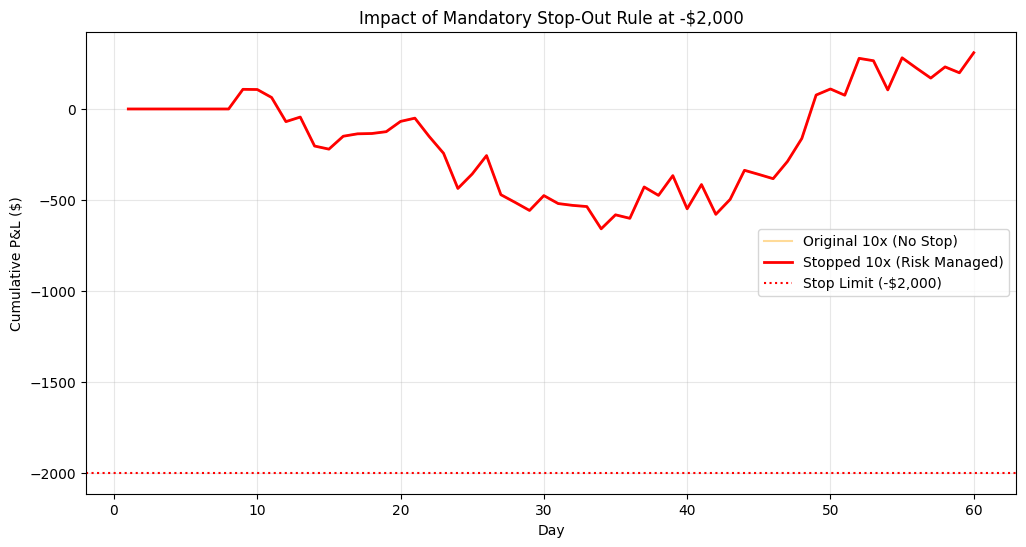

The strategy never dropped below -$2,000. No stop-out occurred.


In [30]:
# Plot comparing the original 10x vs the Stopped 10x
plt.figure(figsize=(12, 6))
plt.plot(df['Day'], df['Cumulative_PnL_10x'], label='Original 10x (No Stop)', color='orange', alpha=0.4)
plt.plot(df['Day'], df['Cumulative_PnL_Stopped'], label='Stopped 10x (Risk Managed)', color='red', linewidth=2)

if stop_day:
    plt.axvline(x=stop_day, color='black', linestyle='--', label=f'Stop Triggered (Day {stop_day})')
    plt.annotate('STOP OUT', xy=(stop_day, stop_limit), xytext=(stop_day+2, stop_limit-500),
                 arrowprops=dict(facecolor='black', shrink=0.05))

plt.axhline(stop_limit, color='red', linestyle=':', label='Stop Limit (-$2,000)')
plt.title('Impact of Mandatory Stop-Out Rule at -$2,000')
plt.xlabel('Day')
plt.ylabel('Cumulative P&L ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Display the table around the stop-out day
if stop_day:
    print(f"--- Strategy stopped on Day {stop_day} ---")
    print(df[['Day', 'Price', 'Action', 'Cumulative_PnL_10x', 'Cumulative_PnL_Stopped']].iloc[max(0, stop_day-5):stop_day+5])
else:
    print("The strategy never dropped below -$2,000. No stop-out occurred.")

No I did not hit the stop-loss rule.


I did not stop, so there was no continuation.

However, if the limit stopped me earlier at a different threshold - for example. at \$-500, would have stopped me around day 28. The strategy would have led to me exiting with a significant loss and any potential recovery would not have eventuated. Therefore, because the strategy tolerated a bigger drawdown, I was able to continue and realise the eventual profits. The strategy did not succeed because it was immediately correct, but because it survived being wrong long enough for the price to reverse.


The strategy is fragile because its success depends heavily on the chosen stop threshold and the ability to tolerate large drawdowns. A tighter stop (such as \$-500) would have reduced the maximum drawdown, but it also would have locked in a permanent loss and eliminated the eventual recovery.Since the $-2000 stop was far below the actual drawdown experienced, it never constrained the strategy, meaning the survival rule did not meaningfully limit risk in this simulation. The strategys overall success is dependent on tolerating large drawdowns, yet is very fragile as changes in the risk constraints may dramatically change the outcomes as it may trigger the chosen stop threshold.

# Part 6: A Tiny Shock

In [31]:
# Choose a 3-day window
shock_days = [15, 16, 17]
df_shock = df.copy()

# Apply the +4 price shock
df_shock.loc[df_shock['Day'].isin(shock_days), 'Price'] += 4

# Recalculate everything for the 10x Stop-Loss Strategy
df_shock['Price_Change'] = df_shock['Price'].diff()
# Use Position from df (which includes any original stop-out) to calculate PnL
df_shock['Daily_PnL_10x_Shocked'] = df_shock['Position'].shift(1) * df_shock['Price_Change'] * (1000 / 50 * 10)
df_shock['Daily_PnL_10x_Shocked'] = df_shock['Daily_PnL_10x_Shocked'].fillna(0)

# Apply Stop-Loss Logic ($ -2,000 threshold) specifically for the shocked scenario
stopped_out_shock = False
stop_day_shock = None
daily_pnl_stopped_shocked = []

current_cum_pnl_shocked = 0
for i in range(len(df_shock)):
    if stopped_out_shock:
        daily_pnl_stopped_shocked.append(0)
    else:
        pnl_today = df_shock['Daily_PnL_10x_Shocked'].iloc[i]
        current_cum_pnl_shocked += pnl_today

        if current_cum_pnl_shocked <= -2000:
            stopped_out_shock = True
            stop_day_shock = df_shock.at[i, 'Day']
            daily_pnl_stopped_shocked.append(pnl_today) # Include the final blow
        else:
            daily_pnl_stopped_shocked.append(pnl_today)

df_shock['Cumulative_PnL_Stopped'] = np.cumsum(daily_pnl_stopped_shocked)


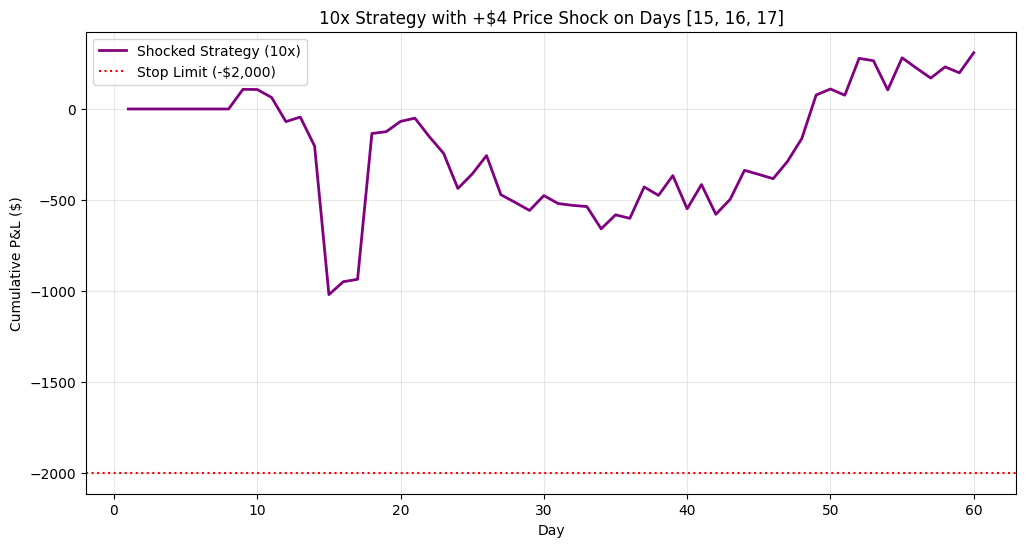

In [32]:
plt.figure(figsize=(12, 6))
plt.plot(df_shock['Day'], df_shock['Cumulative_PnL_Stopped'], color='purple', linewidth=2, label='Shocked Strategy (10x)')
plt.axhline(-2000, color='red', linestyle=':', label='Stop Limit (-$2,000)')

if stop_day_shock:
    plt.scatter(stop_day_shock, df_shock.loc[df_shock['Day']==stop_day_shock, 'Cumulative_PnL_Stopped'],
                color='black', zorder=5, label=f'Liquidated Day {stop_day_shock}')

plt.title(f'10x Strategy with +$4 Price Shock on Days {shock_days}')
plt.xlabel('Day')
plt.ylabel('Cumulative P&L ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [33]:
print(f"--- Shocked Strategy Performance around Days {shock_days} ---")
print(df_shock[['Day', 'Price', 'Position', 'Daily_PnL_10x_Shocked', 'Cumulative_PnL_Stopped']].iloc[shock_days[0]-2 : shock_days[-1]+2])

--- Shocked Strategy Performance around Days [15, 16, 17] ---
    Day      Price  Position  Daily_PnL_10x_Shocked  Cumulative_PnL_Stopped
13   14  53.142763        -1              -159.3110               -203.7246
14   15  57.228172        -1              -817.0818              -1020.8064
15   16  56.873545        -1                70.9254               -949.8810
16   17  56.807033        -1                13.3024               -936.5786
17   18  52.798354        -1               801.7358               -134.8428
18   19  52.747808        -1                10.1092               -124.7336


In [34]:
print(f"Final Cumulative P&L (Original 1x Leverage): ${df['Cumulative_PnL'].iloc[-1]:.2f}")
print(f"Final Cumulative P&L (10x Leveraged Strategy): ${df['Cumulative_PnL_10x'].iloc[-1]:.2f}")
print(f"Final Cumulative P&L (Stopped 10x Leveraged Strategy): ${df['Cumulative_PnL_Stopped'].iloc[-1]:.2f}")
print(f"Final Cumulative P&L (Shocked 10x Leveraged Strategy): ${df_shock['Cumulative_PnL_Stopped'].iloc[-1]:.2f}")

Final Cumulative P&L (Original 1x Leverage): $30.93
Final Cumulative P&L (10x Leveraged Strategy): $309.34
Final Cumulative P&L (Stopped 10x Leveraged Strategy): $309.34
Final Cumulative P&L (Shocked 10x Leveraged Strategy): $309.34


No the shock did not change the final profits. The final profits remained at \$309.34. This is likely bececause the shock occured early on the the trading window which allowed the profits to recover over the remainder of the window. Fundamentally, the price shock changes the risk exposure, even while the ending profit was the same.



No it did not change whether I survived as it did not get close to the \$2000 stop limit. The lowest value it got to was \$-1020.8064 on day 15, meaning there was a buffer of \$979~. However, this is a significant changes as it represents roughly a 55% increase in the maximum drawdown from just a 3-day \$4 price shock. The closest the buffer was to the lowest value prior to the shock was \$1342, meaning the shock reduced the buffer by roughly \$360. Although the final profits didnt change, the risk profile drastically shifted.


Overall, the rule mattered more as the price shock did not impact the overall profits. This meant that althought the shock may have affected profits in the short-term, it played no significant impact on the overall returns for this time period. While we never encountered a situation where the price stop limit was reached, the rule is still ultimately more important as it would have determined overall survival, by stopping a significant loss in the realm where the cummulative profits would not have been able to recover. However it is important to note, that the shock is still important - it chnaged how close I came to hitting the stop marker meaning it could have potentially been more important. The rule in this instance regulates the boundary of loss, while the short-run luck experienced by the shocl determines how close we land to that boundary. Based on this specific simulation, the stop rule ultimately determined survival because the shock did not push the strategy beyond the loss boundary. However, the shock significantly reduced the margin of safety, demonstrating that short-run path changes can  affect how fragile survival becomes.


